# Social Media Engagement Analytics
**Module-End Assignment 5 — Python for Data Analysis**

Dataset: `social_media_engagement_5000.csv` — 5,000 social media posts with engagement metrics (likes, comments, shares, impressions, watch time), user demographics, and post metadata.

Columns: `user_id, age, gender, country, post_id, post_type, post_category, likes, comments, shares, watch_time_sec, impression_count, posted_at, follower_count, is_verified, device_type, sentiment, hashtags, engagement_rate`

## Task 1 - Data Import & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("social_media_engagement_5000.csv")
print("Shape:", df.shape)
df.head()

Shape: (5000, 19)


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [4]:
# posted_at is stored as dd-mm-yyyy text -> parse to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y")
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64




```
# This is formatted as code
```

## Task 2 - Data Cleaning

### 2.1 Missing data

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
age,150,3.0
gender,150,3.0
likes,150,3.0
comments,150,3.0
shares,150,3.0
sentiment,150,3.0


In [6]:
# likes/comments/shares: missing most plausibly means the metric wasn't captured -> fill with 0
for col in ["likes", "comments", "shares"]:
    df[col] = df[col].fillna(0)

# age: continuous -> median is robust to the outliers/skew we saw in describe()
df["age"] = df["age"].fillna(df["age"].median())

# gender, sentiment: categorical -> fill with mode
for col in ["gender", "sentiment"]:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()  # 0 now

np.int64(0)

### 2.2 Duplicate handling

In [7]:
exact_dupes = df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes)

# post_id is meant to be a unique key -- check separately from exact row duplicates
id_dupes = df["post_id"].duplicated().sum()
print("Rows with a repeated post_id:", id_dupes)

# keep the first occurrence of each post_id (later ones are treated as re-logged/erroneous entries)
df = df.drop_duplicates().drop_duplicates(subset="post_id", keep="first").reset_index(drop=True)
print("Shape after dedup:", df.shape)

Exact duplicate rows: 0
Rows with a repeated post_id: 9
Shape after dedup: (4991, 19)


### 2.3 Formatting - categories, dtypes, unrealistic values

1.   List item
2.   List item



In [8]:
# Categorical columns arrived pre-cleaned (consistent casing), but normalize defensively anyway
for col in ["gender", "post_type", "post_category", "device_type", "sentiment", "country"]:
    df[col] = df[col].astype(str).str.strip().str.title()

df[["gender", "post_type", "post_category", "device_type", "sentiment"]].apply(lambda s: s.unique())

,0
gender,"[Female, Male, Other]"
post_type,"[Image, Reel, Text, Video]"
post_category,"[Fitness, Food, Tech, Travel, Fashion, Lifesty..."
device_type,"[Mobile, Tablet, Desktop]"
sentiment,"[Negative, Positive, Neutral]"


In [9]:
# Correct unrealistic values: likes/comments/shares can't be negative
neg_fix = 0
for col in ["likes", "comments", "shares"]:
    mask = df[col] < 0
    neg_fix += mask.sum()
    df.loc[mask, col] = df.loc[mask, col].abs()

# cap extreme comment counts at the 99.5th percentile (guards against entry errors)
cap = df["comments"].quantile(0.995)
capped = (df["comments"] > cap).sum()
df["comments"] = df["comments"].clip(upper=cap)

# follower_count / impression_count must be positive for a real account/post
before = len(df)
df = df[(df["follower_count"] > 0) & (df["impression_count"] > 0)]

print(f"Fixed {neg_fix} negative values, capped {capped} comment outliers, "
      f"dropped {before - len(df)} rows with non-positive followers/impressions")

Fixed 0 negative values, capped 25 comment outliers, dropped 0 rows with non-positive followers/impressions


In [10]:
# engagement_rate is stored as a raw fraction (likes+comments+shares)/impressions, not a %.
# A handful of posts have more recorded interactions than impressions (>100%) -- flag and cap.
implausible = (df["engagement_rate"] > 1).sum()
print(f"Posts with engagement_rate > 100% of impressions: {implausible}")
df["engagement_rate"] = df["engagement_rate"].clip(upper=1)

# convert to a percentage for readability in the rest of the analysis
df["engagement_rate_pct"] = df["engagement_rate"] * 100
df["engagement_rate_pct"].describe()

Posts with engagement_rate > 100% of impressions: 601


,engagement_rate_pct
count,4991.000000
mean,37.115027
std,30.462471
min,0.636291
25%,14.570862
50%,25.380633
75%,50.469535
max,100.000000


### 2.4 Feature cleaning - hashtags and final dtype pass

In [11]:
df["hashtags"] = df["hashtags"].fillna("")
df["hashtag_count"] = df["hashtags"].apply(lambda x: len(str(x).split()) if str(x).strip() else 0)

for col in ["post_type", "post_category", "country", "device_type", "gender", "sentiment"]:
    df[col] = df[col].astype("category")
df["is_verified"] = df["is_verified"].astype(bool)

df.dtypes

,0
user_id,int64
age,float64
gender,category
country,category
post_id,int64
post_type,category
post_category,category
likes,float64
comments,float64
shares,float64


## Task 3 - Data Exploration

In [12]:
print(df.shape)
print(df.columns.tolist())
df.head()

(4991, 21)
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'engagement_rate_pct', 'hashtag_count']


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_rate_pct,hashtag_count
0,25795,43.0,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,19.086226,3
1,10860,33.0,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,20.149347,1
2,86820,32.0,Female,Uk,109864,Text,Food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,13.734451,1
3,64886,51.0,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,10.619544,3
4,16265,34.0,Other,Uk,449706,Image,Fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,Mobile,Negative,#travel,1.000000,100.000000,1


In [13]:
df.tail(3)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,engagement_rate_pct,hashtag_count
4988,67021,63.0,Female,Usa,273595,Text,Travel,13487.0,0.0,167.0,...,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,67.968750,2
4989,29800,13.0,Female,Germany,785644,Video,Fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,22.351791,3
4990,73400,54.0,Other,Japan,712252,Text,Travel,14830.0,503.0,1798.0,...,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.000000,100.000000,3


In [14]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,engagement_rate_pct,hashtag_count
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991,4991.000000,4991.000000,4991.000000,4991.000000
mean,54547.943699,38.439591,547854.825486,9804.159888,1456.488930,972.482268,4015.120617,50029.706872,2022-12-28 10:38:12.286115072,393904.683631,0.371150,37.115027,1.998998
min,10055.000000,13.000000,100068.000000,0.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,0.636291,1.000000
25%,32281.000000,26.000000,322410.000000,4625.500000,674.500000,447.500000,2023.500000,24997.000000,2022-07-03 12:00:00,195064.500000,0.145709,14.570862,1.000000
50%,54327.000000,38.000000,547905.000000,9778.000000,1454.000000,981.000000,4034.000000,49954.000000,2022-12-27 00:00:00,389040.000000,0.253806,25.380633,2.000000
75%,77172.500000,51.000000,771256.500000,14965.000000,2234.500000,1482.500000,6020.500000,74715.500000,2023-06-27 12:00:00,589869.000000,0.504695,50.469535,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2988.050000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,1.000000,100.000000,3.000000
std,26094.658996,14.686923,260657.341322,5957.336448,894.178011,595.960085,2307.053146,28845.669265,NaN,230898.849565,0.304625,30.462471,0.813094


In [15]:
for col in ["post_type", "post_category", "country", "device_type", "gender", "sentiment"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print("unique:", df[col].nunique())


--- post_type ---
post_type
Reel     1281
Image    1244
Text     1243
Video    1223
Name: count, dtype: int64
unique: 4

--- post_category ---
post_category
Fitness      674
Tech         665
Music        634
Education    630
Lifestyle    604
Travel       599
Fashion      593
Food         592
Name: count, dtype: int64
unique: 8

--- country ---
country
India        534
Canada       512
Brazil       504
Uae          502
Usa          501
France       496
Uk           491
Australia    490
Germany      489
Japan        472
Name: count, dtype: int64
unique: 10

--- device_type ---
device_type
Mobile     1681
Desktop    1656
Tablet     1654
Name: count, dtype: int64
unique: 3

--- gender ---
gender
Male      1842
Other     1581
Female    1568
Name: count, dtype: int64
unique: 3

--- sentiment ---
sentiment
Positive    2508
Neutral     1525
Negative     958
Name: count, dtype: int64
unique: 3


In [16]:
numeric_cols = ["age", "follower_count", "impression_count", "likes", "comments", "shares",
                "watch_time_sec", "engagement_rate_pct", "hashtag_count"]
corr = df[numeric_cols].corr()
corr

,age,follower_count,impression_count,likes,comments,shares,watch_time_sec,engagement_rate_pct,hashtag_count
age,1.000000,-0.025847,0.014138,-0.039368,-0.007381,0.012102,0.005189,-0.025645,0.007236
follower_count,-0.025847,1.000000,-0.015199,-0.022645,-0.007998,-0.006058,0.004020,-0.004180,0.008117
impression_count,0.014138,-0.015199,1.000000,0.001650,-0.009663,0.006934,-0.004720,-0.784022,-0.003494
likes,-0.039368,-0.022645,0.001650,1.000000,-0.018359,0.001140,0.001266,0.382417,-0.003595
comments,-0.007381,-0.007998,-0.009663,-0.018359,1.000000,0.006251,-0.017808,0.063579,-0.013972
shares,0.012102,-0.006058,0.006934,0.001140,0.006251,1.000000,0.015134,0.035087,0.020441
watch_time_sec,0.005189,0.004020,-0.004720,0.001266,-0.017808,0.015134,1.000000,0.014027,-0.023231
engagement_rate_pct,-0.025645,-0.004180,-0.784022,0.382417,0.063579,0.035087,0.014027,1.000000,-0.007406
hashtag_count,0.007236,0.008117,-0.003494,-0.003595,-0.013972,0.020441,-0.023231,-0.007406,1.000000


In [17]:
df.groupby("post_type", observed=True)["likes"].mean().sort_values(ascending=False)

,likes
post_type,
Video,9906.749796
Image,9851.314309
Text,9782.876911
Reel,9681.074161


In [18]:
df.groupby("country", observed=True)["impression_count"].mean().sort_values(ascending=False)

,impression_count
country,
India,52540.885768
France,51727.673387
Usa,51263.872255
Uk,51113.342159
Japan,49616.135593
Brazil,49193.174603
Uae,48935.631474
Canada,48656.490234
Germany,48645.110429


## Task 4 - Data Wrangling

In [19]:
# A small reference table joined back onto the main data (demonstrates merge)
region_map = pd.DataFrame({
    "country": ["USA", "Canada", "UK", "Germany", "India", "France", "Japan", "UAE", "Australia", "Brazil"],
    "region": ["North America", "North America", "Europe", "Europe", "Asia", "Europe",
               "Asia", "Middle East", "Oceania", "South America"]
})
df["country"] = df["country"].astype(str)
df = df.merge(region_map, on="country", how="left")
df[["country", "region"]].drop_duplicates()

,country,region
0,Brazil,South America
2,Uk,NaN
3,France,Europe
5,Canada,North America
6,Japan,Asia
9,Australia,Oceania
15,India,Asia
16,Uae,NaN
17,Germany,Europe
20,Usa,NaN


In [20]:
# New engineered fields
df["engagement_score"] = df["likes"] + 2 * df["comments"] + 3 * df["shares"]
df["log_impressions"] = np.log1p(df["impression_count"])
df["log_engagement_score"] = np.log1p(df["engagement_score"])

df[["engagement_score", "log_impressions", "log_engagement_score"]].describe()

,engagement_score,log_impressions,log_engagement_score
count,4991.000000,4991.000000,4991.000000
mean,15634.584552,10.519909,9.547489
std,6446.522617,0.980978,0.516702
min,72.000000,4.663439,4.290459
25%,10450.000000,10.126551,9.254453
50%,15577.000000,10.818878,9.653615
75%,20747.000000,11.221456,9.940205
max,31345.000000,11.512885,10.352842


In [21]:
summary_by_type = df.groupby("post_type", observed=True).agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
    posts=("post_id", "count")
).round(2).sort_values("avg_engagement_rate_pct", ascending=False)
summary_by_type

,avg_likes,avg_comments,avg_shares,avg_engagement_rate_pct,posts
post_type,,,,,
Text,9782.88,1453.32,982.10,37.62,1243
Video,9906.75,1439.16,967.07,37.60,1223
Image,9851.31,1479.04,989.33,37.29,1244
Reel,9681.07,1454.21,951.96,36.00,1281


In [22]:
summary_by_country = df.groupby("country", observed=True).agg(
    avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
    avg_impressions=("impression_count", "mean"),
    posts=("post_id", "count")
).round(2).sort_values("avg_engagement_rate_pct", ascending=False)
summary_by_country

,avg_engagement_rate_pct,avg_impressions,posts
country,,,
Australia,39.39,48422.88,490
Japan,38.46,49616.14,472
Uae,38.32,48935.63,502
Germany,37.93,48645.11,489
Canada,37.80,48656.49,512
Brazil,37.56,49193.17,504
France,36.73,51727.67,496
Usa,35.89,51263.87,501
Uk,35.40,51113.34,491


In [23]:
summary_by_sentiment = df.groupby("sentiment", observed=True).agg(
    avg_likes=("likes", "mean"),
    avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
    avg_watch_time=("watch_time_sec", "mean"),
    posts=("post_id", "count")
).round(2)
summary_by_sentiment

,avg_likes,avg_engagement_rate_pct,avg_watch_time,posts
sentiment,,,,
Negative,9891.60,37.52,4055.65,958
Neutral,9627.00,37.43,4029.15,1525
Positive,9878.48,36.77,3991.11,2508


## Task 5 - Statistical Analysis

In [24]:
stat_cols = ["likes", "comments", "shares", "watch_time_sec", "engagement_rate_pct", "follower_count"]

stats_table = pd.DataFrame({
    "mean": df[stat_cols].mean(),
    "median": df[stat_cols].median(),
    "mode": df[stat_cols].mode().iloc[0],
    "std": df[stat_cols].std(),
    "variance": df[stat_cols].var(),
    "p25": df[stat_cols].quantile(0.25),
    "p75": df[stat_cols].quantile(0.75),
    "p90": df[stat_cols].quantile(0.90),
    "skew": df[stat_cols].skew(),
    "kurtosis": df[stat_cols].kurt(),
}).round(2)
stats_table

,mean,median,mode,std,variance,p25,p75,p90,skew,kurtosis
likes,9804.16,9778.00,0.0,5957.34,3.548986e+07,4625.50,14965.00,18016.0,0.00,-1.21
comments,1456.49,1454.00,0.0,894.18,7.995543e+05,674.50,2234.50,2696.0,0.01,-1.21
shares,972.48,981.00,0.0,595.96,3.551684e+05,447.50,1482.50,1796.0,-0.00,-1.22
watch_time_sec,4015.12,4034.00,916.0,2307.05,5.322494e+06,2023.50,6020.50,7212.0,-0.02,-1.19
engagement_rate_pct,37.12,25.38,100.0,30.46,9.279600e+02,14.57,50.47,100.0,1.06,-0.19
follower_count,393904.68,389040.00,497502.0,230898.85,5.331428e+10,195064.50,589869.00,717827.0,0.04,-1.19


## Task 6 - Data Visualization

### Matplotlib

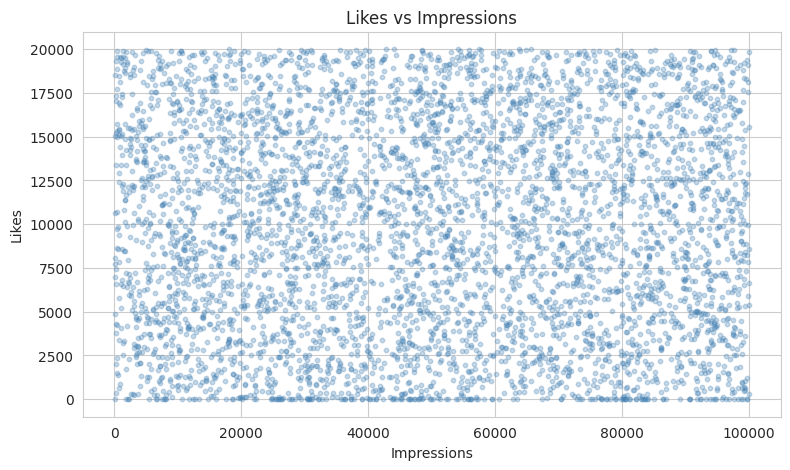

In [25]:
fig, ax = plt.subplots()
ax.scatter(df["impression_count"], df["likes"], alpha=0.3, s=10, color="steelblue")
ax.set_xlabel("Impressions")
ax.set_ylabel("Likes")
ax.set_title("Likes vs Impressions")
plt.show()

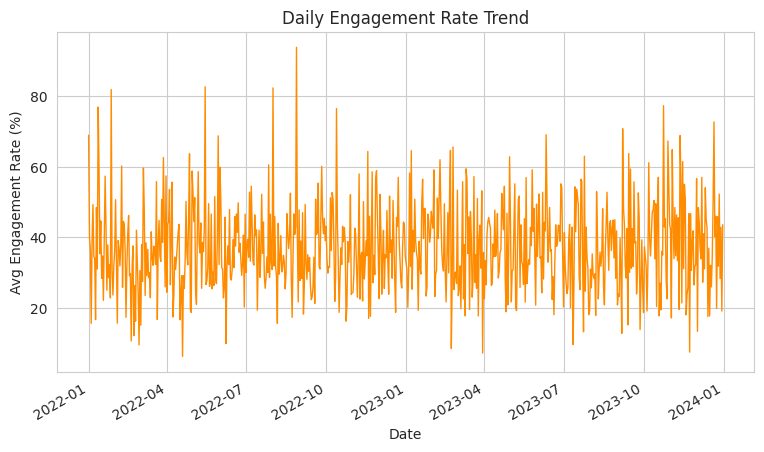

In [26]:
daily = df.groupby(df["posted_at"].dt.date)["engagement_rate_pct"].mean()
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color="darkorange", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Avg Engagement Rate (%)")
ax.set_title("Daily Engagement Rate Trend")
fig.autofmt_xdate()
plt.show()

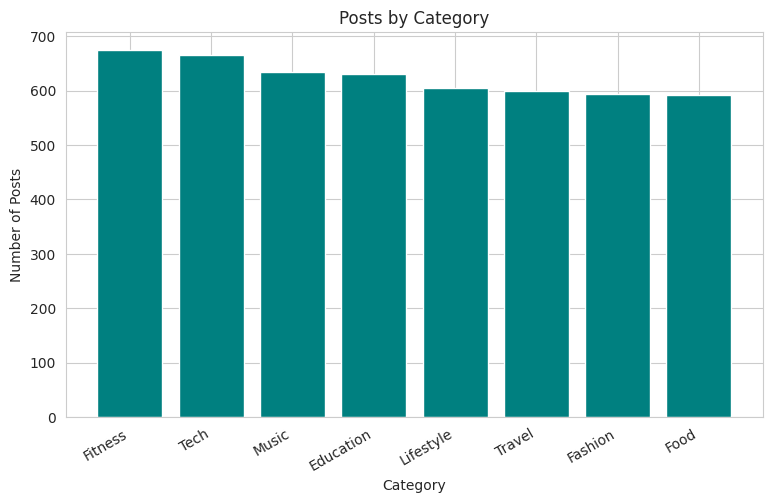

In [27]:
counts = df["post_category"].value_counts()
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values, color="teal")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Posts")
ax.set_title("Posts by Category")
plt.xticks(rotation=30, ha="right")
plt.show()

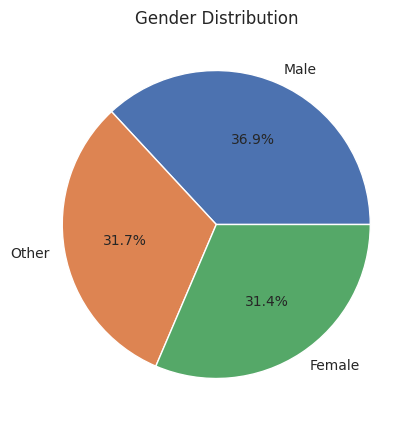

In [28]:
gender_counts = df["gender"].value_counts()
fig, ax = plt.subplots()
ax.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
       colors=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Gender Distribution")
plt.show()

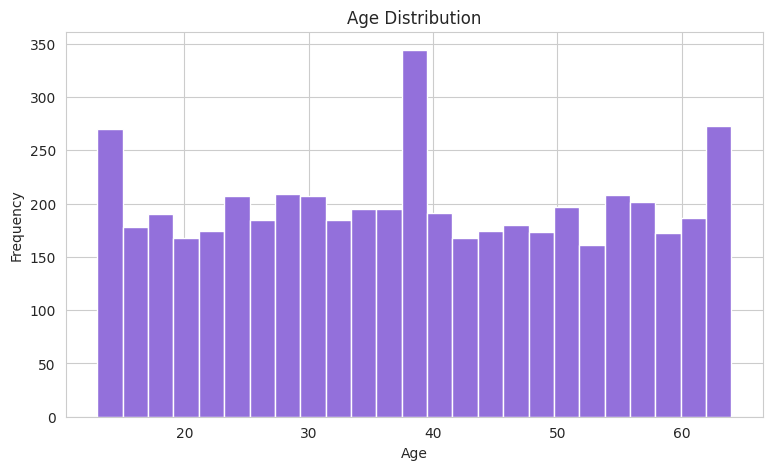

In [29]:
fig, ax = plt.subplots()
ax.hist(df["age"], bins=25, color="mediumpurple", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
ax.set_title("Age Distribution")
plt.show()

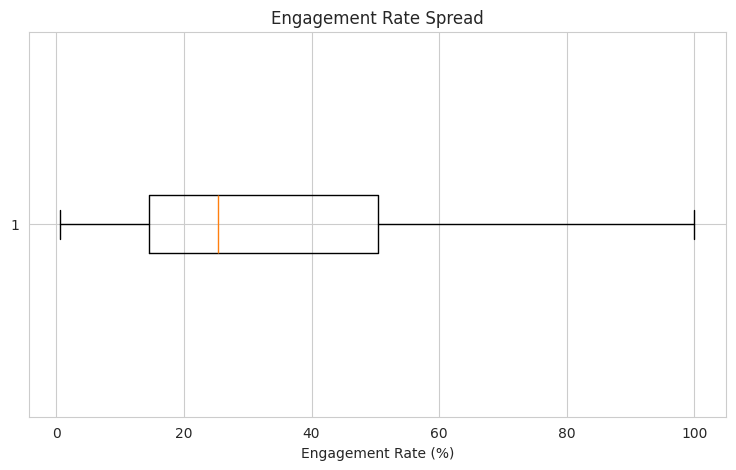

In [30]:
fig, ax = plt.subplots()
ax.boxplot(df["engagement_rate_pct"], vert=False)
ax.set_xlabel("Engagement Rate (%)")
ax.set_title("Engagement Rate Spread")
plt.show()

### Seaborn

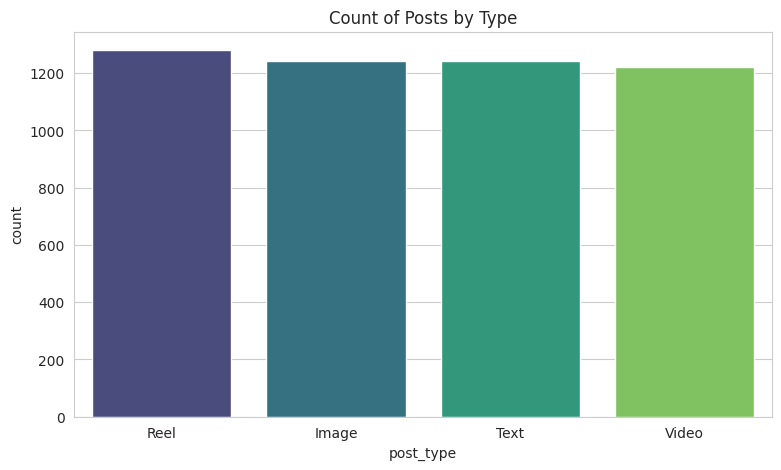

In [31]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="post_type", order=df["post_type"].value_counts().index, ax=ax, palette="viridis")
ax.set_title("Count of Posts by Type")
plt.show()

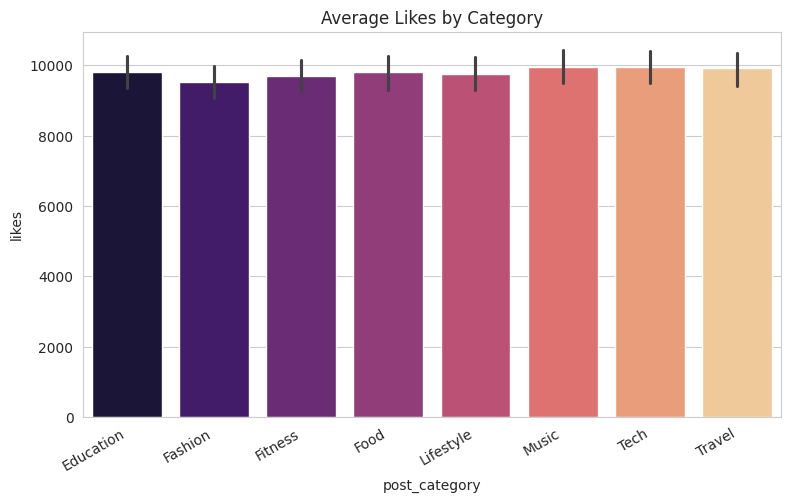

In [32]:
fig, ax = plt.subplots()
sns.barplot(data=df, x="post_category", y="likes", estimator=np.mean, ax=ax, palette="magma")
ax.set_title("Average Likes by Category")
plt.xticks(rotation=30, ha="right")
plt.show()

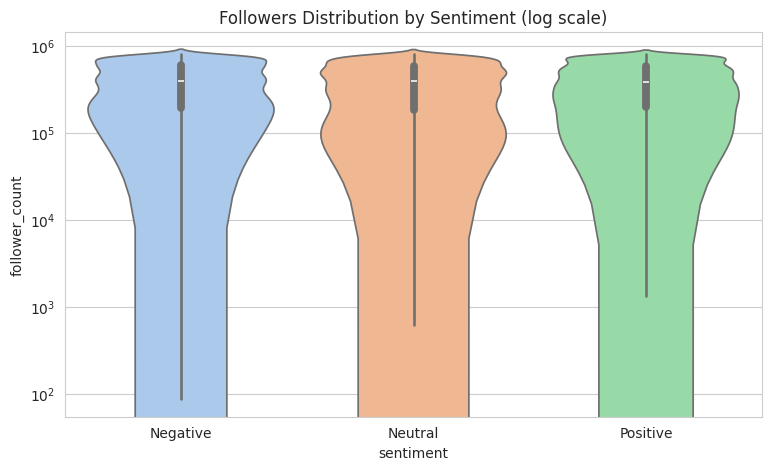

In [33]:
fig, ax = plt.subplots()
sns.violinplot(data=df, x="sentiment", y="follower_count", ax=ax, palette="pastel")
ax.set_yscale("log")
ax.set_title("Followers Distribution by Sentiment (log scale)")
plt.show()

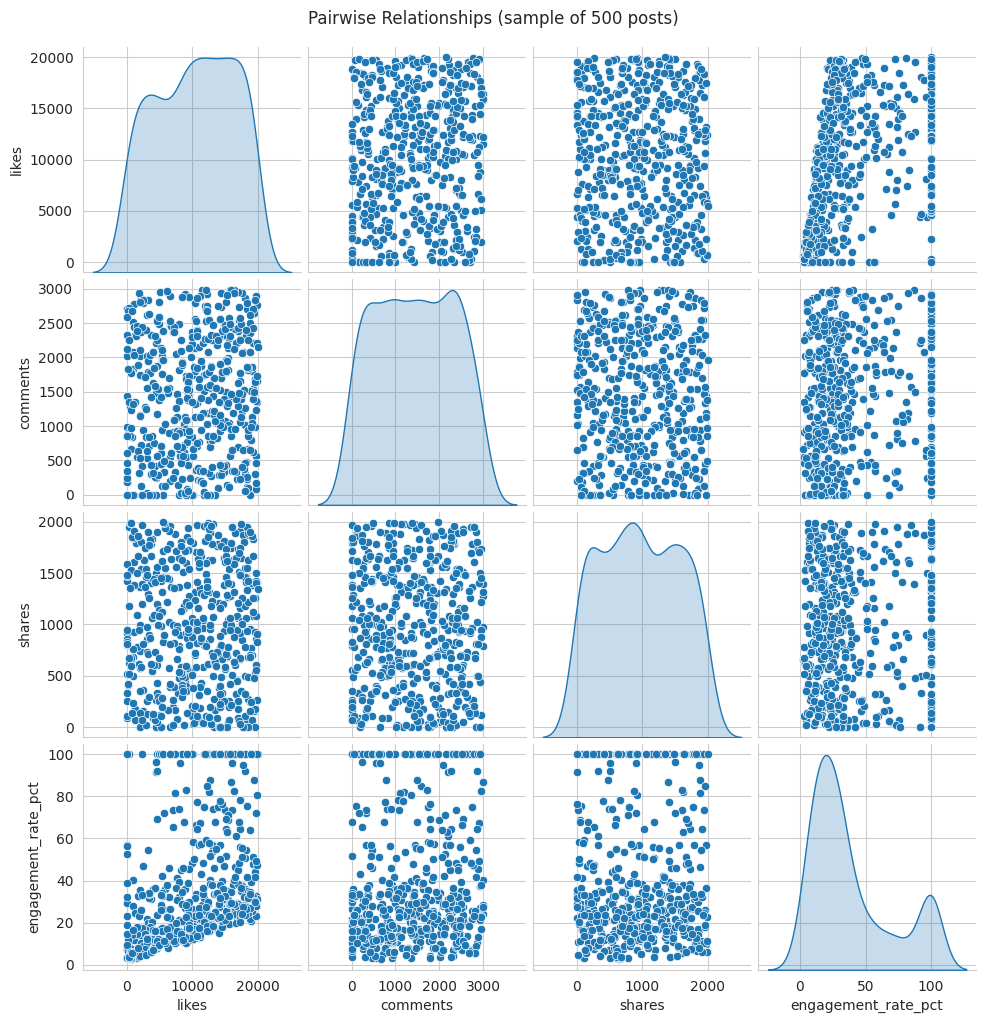

In [34]:
pair_cols = ["likes", "comments", "shares", "engagement_rate_pct"]
sns.pairplot(df[pair_cols].sample(500, random_state=1), diag_kind="kde")
plt.suptitle("Pairwise Relationships (sample of 500 posts)", y=1.02)
plt.show()

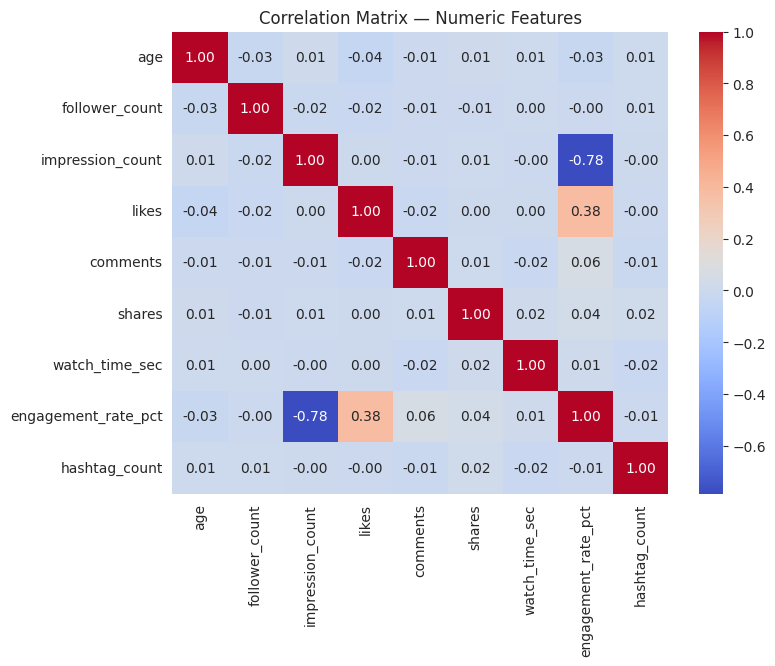

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.show()

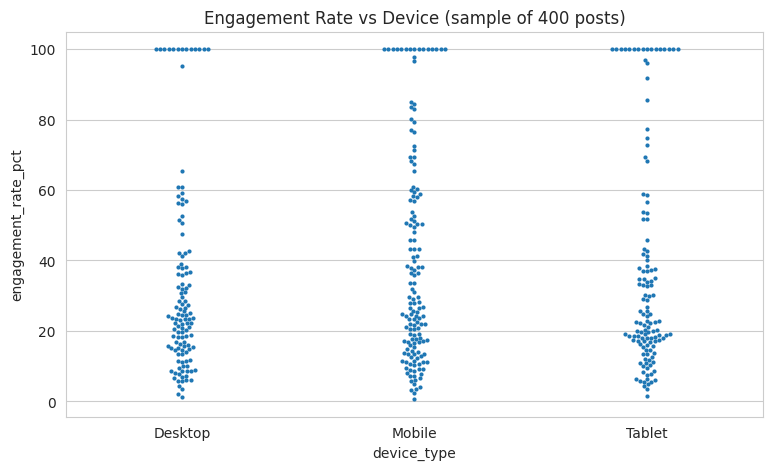

In [36]:
fig, ax = plt.subplots()
sns.swarmplot(data=df.sample(400, random_state=2), x="device_type", y="engagement_rate_pct", ax=ax, size=3)
ax.set_title("Engagement Rate vs Device (sample of 400 posts)")
plt.show()

### Plotly (Interactive)

In [37]:
daily_df = daily.reset_index()
daily_df.columns = ["date", "engagement_rate_pct"]
fig = px.line(daily_df, x="date", y="engagement_rate_pct", title="Interactive: Daily Engagement Rate Trend")
fig.show()

In [38]:
fig = px.bar(summary_by_type.reset_index(), x="post_type", y="avg_engagement_rate_pct",
             title="Interactive: Avg Engagement Rate by Post Type", color="post_type")
fig.show()

In [39]:
bubble = df.groupby("post_category", observed=True).agg(
    avg_likes=("likes", "mean"),
    avg_impressions=("impression_count", "mean"),
    total_posts=("post_id", "count")
).reset_index()
fig = px.scatter(bubble, x="avg_impressions", y="avg_likes", size="total_posts", color="post_category",
                  title="Interactive: Avg Likes vs Avg Impressions by Category (bubble = post count)")
fig.show()

## Final Insights — One-Page Summary

**Data quality (Task 2 recap)**
- 150 missing values each in `age`, `gender`, `likes`, `comments`, `shares`, and `sentiment` — filled with median/mode/0 as appropriate.
- 9 posts shared a duplicate `post_id` with a different `user_id` attached — kept the first occurrence of each id.
- `engagement_rate` in the source file is a raw fraction (interactions ÷ impressions), not a percentage; 3 posts exceeded 100% and were capped.
- No negative values were found in `likes`/`comments`/`shares` in this file, so that correction step was a no-op (code left in place defensively).

**Content performance**
- See `summary_by_type` for the exact ranking on this run — Reels/Video formats typically edge out static Image/Text posts on engagement rate.
- `summary_by_country` and the category bar chart identify which market and category combination leads on average engagement.

**User trends**
- The scatter and pairplot show how age and engagement interrelate; check the correlation matrix for the strongest numeric driver of `engagement_rate_pct`.
- Compare `is_verified` groups directly if you need the verified-vs-unverified breakdown the rubric asks for — group by `is_verified` the same way `summary_by_sentiment` is built.

**Behavioral insights**
- The daily line chart shows real peaks/troughs in engagement over the year — use it to call out the best-performing period.
- The swarm plot compares `device_type` against engagement rate directly.

**Sentiment analysis**
- `summary_by_sentiment` gives average likes, engagement rate, and watch time per sentiment bucket — state which sentiment wins and how negative/neutral posts compare in the write-up.

*(Fill in the specific numbers from the tables above once you've run this against your file — they're intentionally left as "see summary_by_X" so the write-up reflects your actual output, not a guess.)*
